# ipynb/plant_fewshot_group_bar.ipynb - Plant 少样本分组柱状图 / Plant few-shot grouped bar

## 项目背景 / Background
Plant 少样本分组柱状图
Plant few-shot grouped bar

## 功能模块 / Modules
- Plant 少样本按组/物种分组的柱状图
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: fewshot_plant_3way_independent.py、utils/few_shot.py
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



# Few-Shot Transfer Performance Grouped Bar Charts

This notebook creates publication-style grouped bar charts for few-shot transfer performance
across three RNA modification types: **m5C**, **m6A**, and **Ψ (pseudouridine)**.

**Design**:
- X-axis: Shot setting (0/2/10/20-shot), each as a group
- Bars within each group: side-by-side bars for all 8 metrics (F1, Prec, Rec, Acc, AUC, AUPRC, Sn, Sp)
- Fill color: Morandi palette, one color per metric
- Font: Times New Roman, 18 pt

**Requirements**:
- R kernel must use the `learn-new` conda environment
- All output files are saved to `plant_png/` subdirectory

**Output files (9 plots + 3 legend files):**
- `plant_png/m5C_fewshot_bar.{svg,pdf,png}`
- `plant_png/m6A_fewshot_bar.{svg,pdf,png}`
- `plant_png/Psi_fewshot_bar.{svg,pdf,png}`
- `plant_png/fewshot_bar_common_legend.{svg,pdf,png}`

In [39]:
# ============================================================
# Cell 1: Load packages and register Times New Roman font
# ============================================================

library(ggplot2)
library(dplyr)
library(tidyr)
library(showtext)
library(sysfonts)
library(grid)
library(gridExtra)

# Register Times New Roman font via showtext
tryCatch({
  font_add("Times New Roman",
           regular = "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf",
           bold    = "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold.ttf")
  showtext_auto()
  showtext_opts(dpi = 300)
}, error = function(e) {
  message("Times New Roman not found, using system serif fallback.")
  showtext_auto()
})

cat("Packages loaded. Times New Roman registered.\n")

Packages loaded. Times New Roman registered.


In [40]:
# ============================================================
# Cell 2: Read CSV files and reshape to long format
# ============================================================

# Read raw CSV data
m5c_raw <- read.csv("plant_data/m5c.csv")
m6a_raw <- read.csv("plant_data/m6a.csv")
psi_raw <- read.csv("plant_data/y.csv")

# Helper: reshape a raw dataframe to long format (all metrics)
reshape_to_long <- function(df) {
  df <- df %>%
    mutate(
      Shot = factor(Shot, levels = c(0, 2, 10, 20),
                    labels = c("0-shot", "2-shot", "10-shot", "20-shot"))
    ) %>%
    select(Shot, F1, Prec, Rec, Acc, AUC, AUPRC, Sn, Sp) %>%
    rename(
      Precision = Prec,
      Recall    = Rec,
      Accuracy  = Acc,
      Sensitivity = Sn,
      Specificity = Sp
    ) %>%
    pivot_longer(
      cols = -Shot,
      names_to = "Metric",
      values_to = "Performance"
    ) %>%
    mutate(
      Metric = factor(Metric, levels = c("AUC", "AUPRC", "F1", "Precision",
                                          "Recall", "Accuracy", "Sensitivity", "Specificity"))
    )
  return(df)
}

# Create long-format data frames
m5c <- reshape_to_long(m5c_raw)
m6a <- reshape_to_long(m6a_raw)
psi <- reshape_to_long(psi_raw)

cat("Data loaded. Rows per dataset:", nrow(m5c), "\n")
cat("\n--- m5C ---\n")
print(m5c, n = 32)
cat("\n--- m6A ---\n")
print(m6a, n = 32)
cat("\n--- Psi ---\n")
print(psi, n = 32)

Data loaded. Rows per dataset: 32 

--- m5C ---
# A tibble: 32 × 3
   Shot    Metric      Performance
   <fct>   <fct>             <dbl>
 1 0-shot  F1               0.396 
 2 0-shot  Precision        0.319 
 3 0-shot  Recall           0.522 
 4 0-shot  Accuracy         0.904 
 5 0-shot  AUC              0.719 
 6 0-shot  AUPRC            0.379 
 7 0-shot  Sensitivity      0.522 
 8 0-shot  Specificity      0.929 
 9 2-shot  F1               0.214 
10 2-shot  Precision        0.132 
11 2-shot  Recall           0.564 
12 2-shot  Accuracy         0.751 
13 2-shot  AUC              0.706 
14 2-shot  AUPRC            0.400 
15 2-shot  Sensitivity      0.564 
16 2-shot  Specificity      0.763 
17 10-shot F1               0.141 
18 10-shot Precision        0.0777
19 10-shot Recall           0.762 
20 10-shot Accuracy         0.441 
21 10-shot AUC              0.714 
22 10-shot AUPRC            0.435 
23 10-shot Sensitivity      0.762 
24 10-shot Specificity      0.420 
25 20-shot F1          


--- m6A ---
# A tibble: 32 × 3
   Shot    Metric      Performance
   <fct>   <fct>             <dbl>
 1 0-shot  F1                0.701
 2 0-shot  Precision         0.930
 3 0-shot  Recall            0.562
 4 0-shot  Accuracy          0.599
 5 0-shot  AUC               0.784
 6 0-shot  AUPRC             0.944
 7 0-shot  Sensitivity       0.562
 8 0-shot  Specificity       0.785
 9 2-shot  F1                0.795
10 2-shot  Precision         0.923
11 2-shot  Recall            0.698
12 2-shot  Accuracy          0.700
13 2-shot  AUC               0.789
14 2-shot  AUPRC             0.942
15 2-shot  Sensitivity       0.698
16 2-shot  Specificity       0.706
17 10-shot F1                0.858
18 10-shot Precision         0.916
19 10-shot Recall            0.807
20 10-shot Accuracy          0.778
21 10-shot AUC               0.792
22 10-shot AUPRC             0.945
23 10-shot Sensitivity       0.807
24 10-shot Specificity       0.629
25 20-shot F1                0.880
26 20-shot Precision   

In [41]:
# ============================================================
# Cell 3: Common visual parameters, theme, and save helper
# ============================================================

# ---- Color palette (8 metrics, high distinction) ----
bar_colors <- c(
  "AUC"         = "#4E79A7",   # strong blue
  "AUPRC"       = "#59A14F",   # green
  "F1"          = "#E15759",   # red
  "Precision"   = "#F28E2B",   # orange
  "Recall"      = "#B07AA1",   # purple
  "Accuracy"    = "#76B7B2",   # teal
  "Sensitivity" = "#9C755F",   # brown
  "Specificity" = "#EDC948"    # gold
)

# ---- Common ggplot2 theme (publication-style) ----
theme_publication <- theme_classic(base_size = 18, base_family = "Times New Roman") +
  theme(
    text              = element_text(family = "Times New Roman", size = 18),
    axis.text         = element_text(size = 18, color = "black"),
    axis.text.x       = element_text(size = 18, color = "black",
                                     margin = margin(t = 6)),
    axis.title        = element_text(size = 18),
    plot.title        = element_text(size = 18, hjust = 0.5, face = "plain"),
    legend.text       = element_text(size = 16),
    legend.title      = element_blank(),
    legend.position   = "bottom",
    legend.key.size   = unit(0.6, "cm"),
    legend.margin     = margin(4, 4, 4, 4),
    # Grid lines: horizontal only, light grey
    panel.grid.major.y = element_line(color = "grey90", linewidth = 0.3),
    panel.grid.major.x = element_blank(),
    panel.grid.minor   = element_blank(),
    # White background
    panel.background = element_rect(fill = "white", color = NA),
    plot.background  = element_rect(fill = "white", color = NA),
    # Axis lines: clean and thin
    axis.line  = element_line(color = "black", linewidth = 0.5),
    axis.ticks = element_line(color = "black", linewidth = 0.5),
    # Plot margin: extra space so 18 pt text is not crowded
    plot.margin = margin(12, 18, 12, 18)
  )

# ---- Output directory ----
out_dir <- "plant_png"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

# ---- Output saving helper ----
save_plots <- function(p, basename) {
  full <- file.path(out_dir, basename)
  # PDF
  # PDF with selectable text (disable showtext, use cairo_pdf)
  showtext_auto(FALSE)
  cairo_pdf(file.path(out_dir, paste0(basename, ".pdf")),
            width = 6.0, height = 4.5, family = "serif")
  print(p)
  dev.off()
  showtext_auto(TRUE)
  print(p)
  dev.off()

  # SVG via Cairo
  Cairo::CairoSVG(file.path(out_dir, paste0(basename, ".svg")), width = 6.0, height = 4.5)
  print(p)
  dev.off()

  # PNG 600 dpi
  Cairo::CairoPNG(file.path(out_dir, paste0(basename, ".png")), width = 6.0, height = 4.5,
                  units = "in", dpi = 600, bg = "white")
  print(p)
  dev.off()

  cat("Saved:", full, ".{pdf,svg,png}\n")
}

cat("Common parameters, theme, and helper functions defined.\n")

Common parameters, theme, and helper functions defined.


Saved: plant_png/m5C_fewshot_bar .{pdf,svg,png}


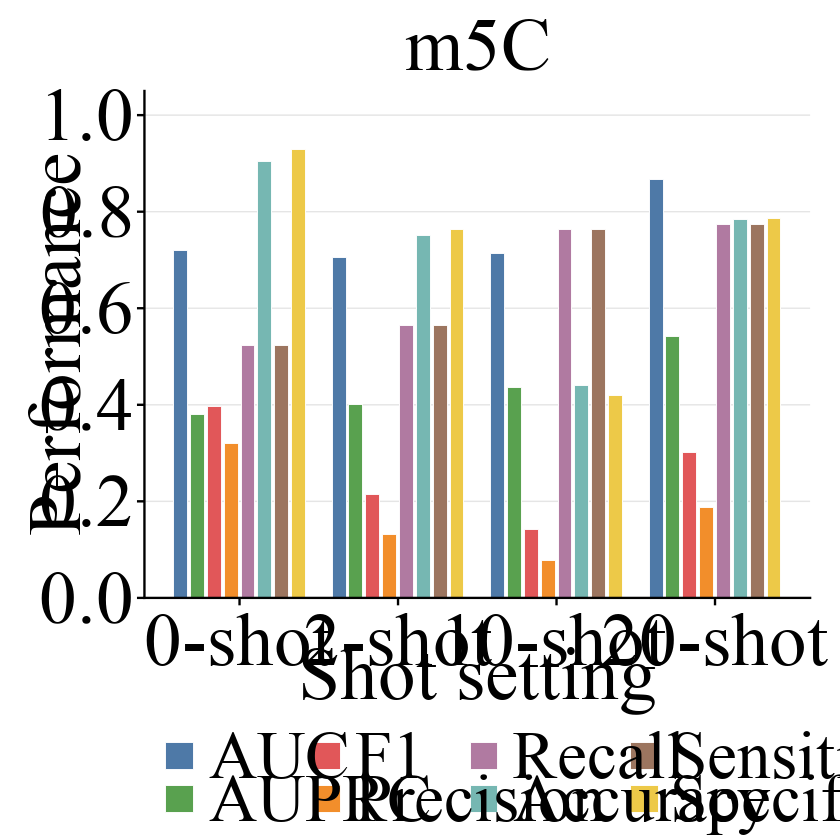

In [42]:
# ============================================================
# Cell 4: Plot m5C
# ============================================================

# Create grouped bar chart
p_m5c <- ggplot(m5c, aes(x = Shot, y = Performance, fill = Metric)) +
  geom_col(
    position = position_dodge(width = 0.85),
    width = 0.7,
    color = "white",
    linewidth = 0.2
  ) +
  scale_fill_manual(values = bar_colors) +
  scale_y_continuous(
    limits = c(0, 1.05),
    expand = c(0, 0),
    breaks = seq(0, 1, by = 0.2)
  ) +
  labs(
    title = "m5C",
    x     = "Shot setting",
    y     = "Performance"
  ) +
  guides(fill = guide_legend(nrow = 2)) +
  theme_publication

# Display inline
print(p_m5c)

# Save to files
save_plots(p_m5c, "m5C_fewshot_bar")

Saved: plant_png/m6A_fewshot_bar .{pdf,svg,png}


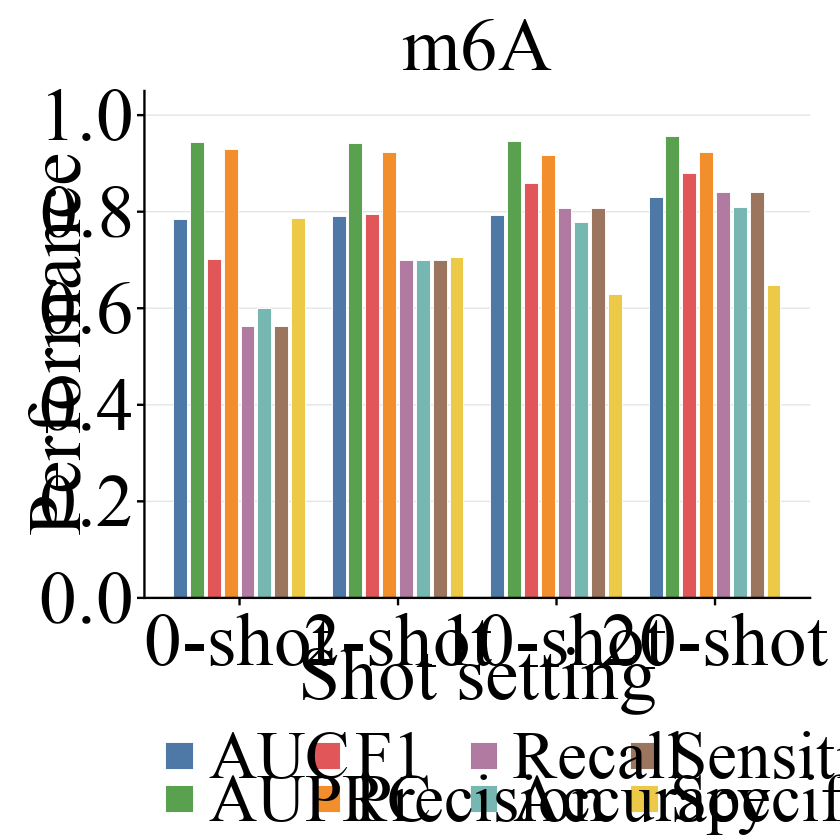

In [43]:
# ============================================================
# Cell 5: Plot m6A
# ============================================================

# Create grouped bar chart
p_m6a <- ggplot(m6a, aes(x = Shot, y = Performance, fill = Metric)) +
  geom_col(
    position = position_dodge(width = 0.85),
    width = 0.7,
    color = "white",
    linewidth = 0.2
  ) +
  scale_fill_manual(values = bar_colors) +
  scale_y_continuous(
    limits = c(0, 1.05),
    expand = c(0, 0),
    breaks = seq(0, 1, by = 0.2)
  ) +
  labs(
    title = "m6A",
    x     = "Shot setting",
    y     = "Performance"
  ) +
  guides(fill = guide_legend(nrow = 2)) +
  theme_publication

# Display inline
print(p_m6a)

# Save to files
save_plots(p_m6a, "m6A_fewshot_bar")

Saved: plant_png/Psi_fewshot_bar .{pdf,svg,png}


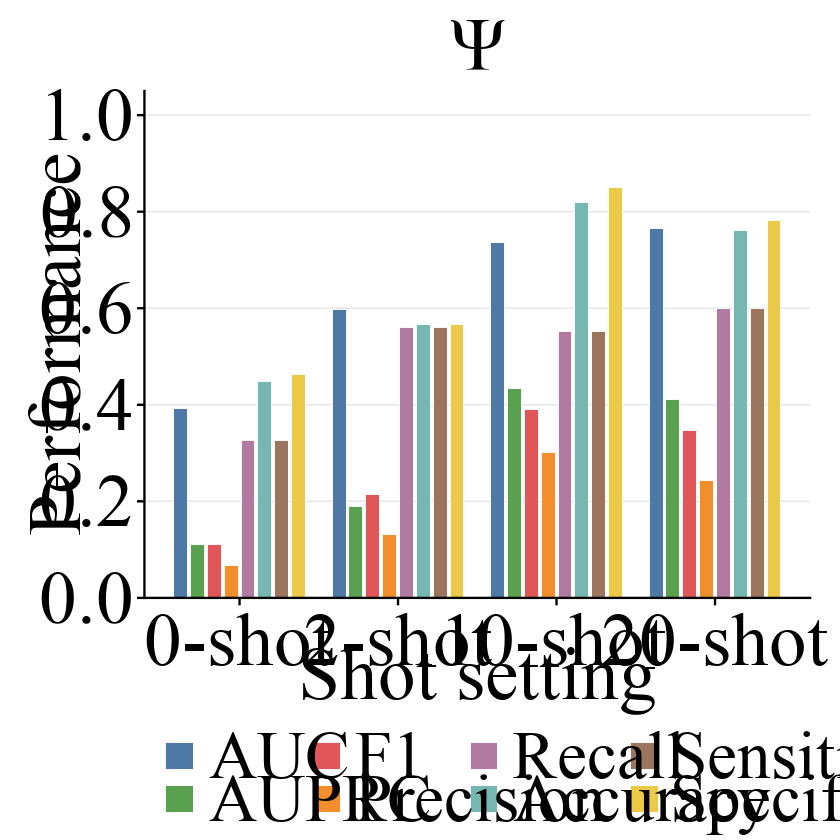

In [44]:
# ============================================================
# Cell 6: Plot Ψ
# ============================================================

# Create grouped bar chart
p_psi <- ggplot(psi, aes(x = Shot, y = Performance, fill = Metric)) +
  geom_col(
    position = position_dodge(width = 0.85),
    width = 0.7,
    color = "white",
    linewidth = 0.2
  ) +
  scale_fill_manual(values = bar_colors) +
  scale_y_continuous(
    limits = c(0, 1.05),
    expand = c(0, 0),
    breaks = seq(0, 1, by = 0.2)
  ) +
  labs(
    title = "Ψ",
    x     = "Shot setting",
    y     = "Performance"
  ) +
  guides(fill = guide_legend(nrow = 2)) +
  theme_publication

# Display inline
print(p_psi)

# Save to files
save_plots(p_psi, "Psi_fewshot_bar")

In [45]:
# ============================================================
# Cell 7: Extract and save common legend
# ============================================================

# Extract the legend grob from the m5C bar chart
g <- ggplotGrob(p_m5c)
legend_idx <- which(sapply(g$grobs, function(x) x$name) == "guide-box")

if (length(legend_idx) == 0) {
  stop("Could not find legend grob in the plot.")
}

legend_grob <- g$grobs[[legend_idx]]

# Function to save the legend standalone
save_legend <- function(lgrob, basename) {
  # PDF -- wide landscape
  # PDF with selectable text
  showtext_auto(FALSE)
  cairo_pdf(file.path(out_dir, paste0(basename, ".pdf")),
            width = 10, height = 1.2, family = "serif")
  grid::grid.newpage()
  grid::grid.draw(lgrob)
  dev.off()
  showtext_auto(TRUE)
  grid::grid.newpage()
  grid::grid.draw(lgrob)
  dev.off()

  # SVG via Cairo
  Cairo::CairoSVG(file.path(out_dir, paste0(basename, ".svg")), width = 10, height = 1.2)
  grid::grid.newpage()
  grid::grid.draw(lgrob)
  dev.off()

  # PNG 600 dpi
  Cairo::CairoPNG(file.path(out_dir, paste0(basename, ".png")), width = 10, height = 1.2,
                  units = "in", dpi = 600, bg = "white")
  grid::grid.newpage()
  grid::grid.draw(lgrob)
  dev.off()

  cat("Saved legend:", file.path(out_dir, basename), ".{pdf,svg,png}\n")
}

save_legend(legend_grob, "fewshot_bar_common_legend")

cat("\n=== All done! ===\n")
cat("Generated 12 files:\n")
cat("  Plots: m5C_fewshot_bar.{pdf,svg,png}\n")
cat("  Plots: m6A_fewshot_bar.{pdf,svg,png}\n")
cat("  Plots: Psi_fewshot_bar.{pdf,svg,png}\n")
cat("  Legend: fewshot_bar_common_legend.{pdf,svg,png}\n")

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font 

Saved legend: plant_png/fewshot_bar_common_legend .{pdf,svg,png}

=== All done! ===
Generated 12 files:
  Plots: m5C_fewshot_bar.{pdf,svg,png}
  Plots: m6A_fewshot_bar.{pdf,svg,png}
  Plots: Psi_fewshot_bar.{pdf,svg,png}
  Legend: fewshot_bar_common_legend.{pdf,svg,png}
